Forced selection dub1: slice_0500.png
trhlina_hniloba_roundness_boundary: 0.15


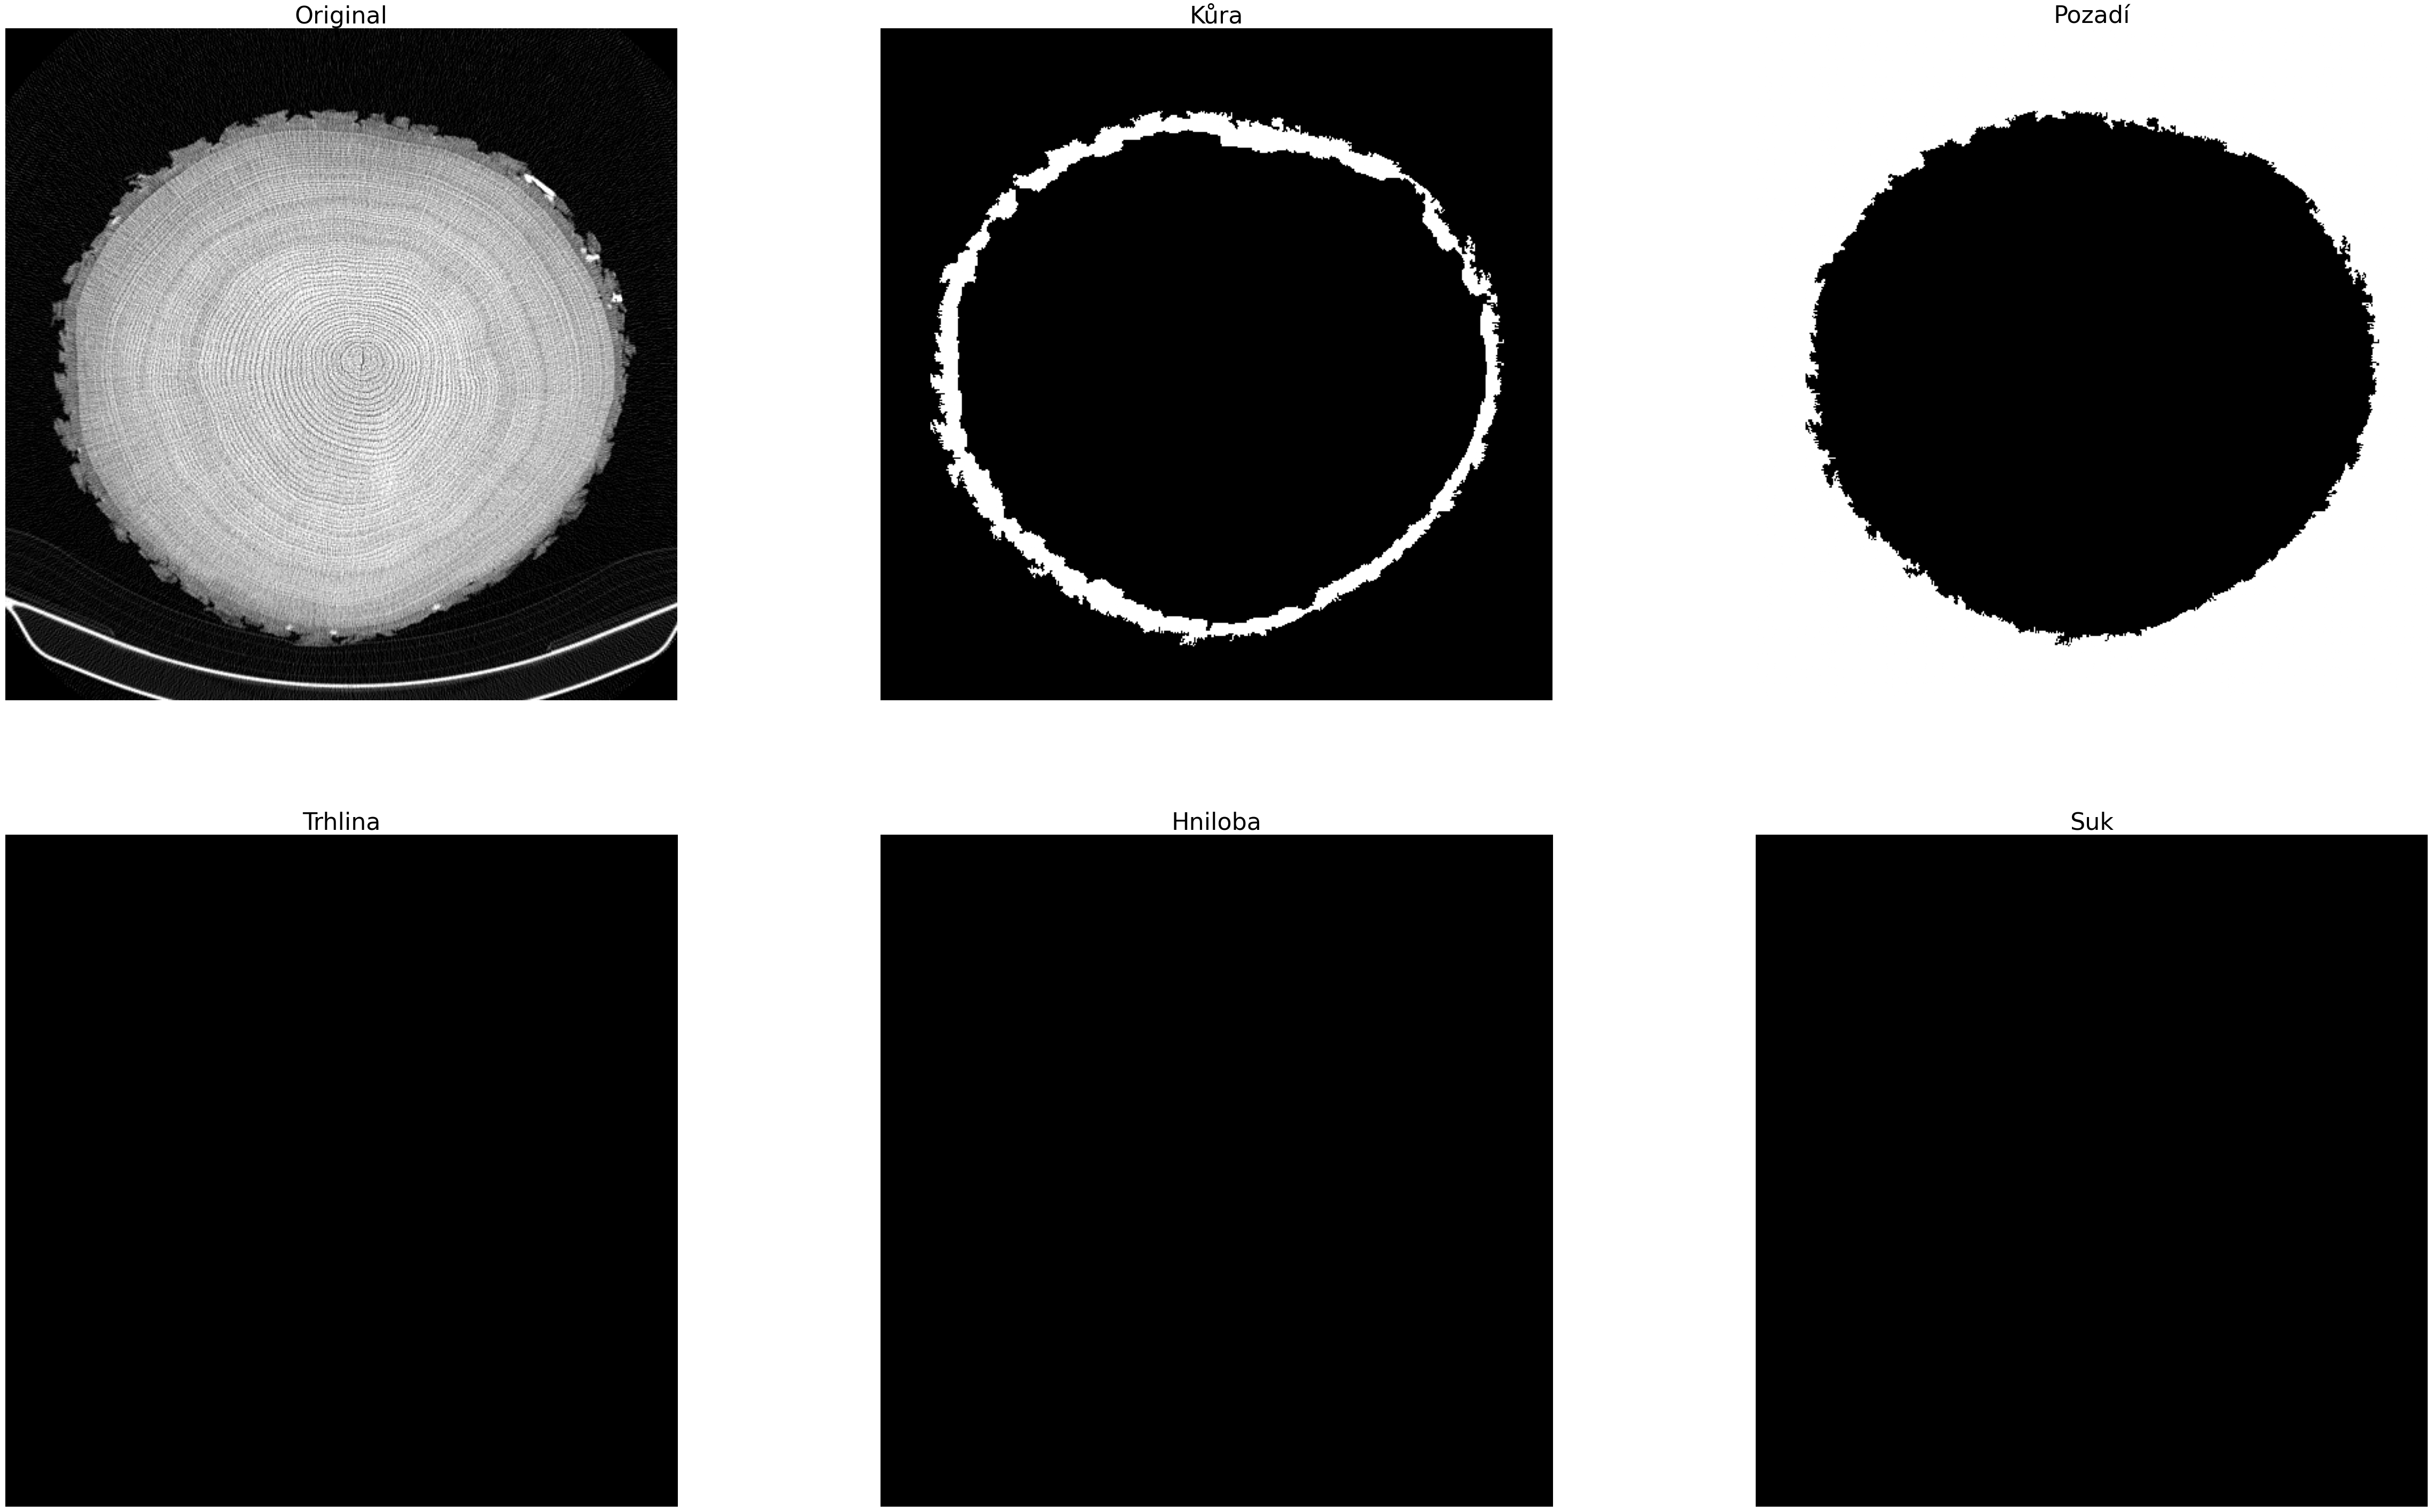

In [1]:
# USED TO SETUP SEGMENTATION INSIDE THE PROJECT

import cv2
import improutils as iu
import random
import importlib
import sys
from pathlib import Path

# --- Resolve project paths robustly (independent of notebook cwd) ---
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root (missing pyproject.toml/src)")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Reload submodules first so segmentation.py picks fresh implementations
importlib.reload(importlib.import_module("src.preprocessing.segmentation.seg_log"))
importlib.reload(importlib.import_module("src.preprocessing.segmentation.seg_kura"))
importlib.reload(importlib.import_module("src.preprocessing.segmentation.seg_suk"))
importlib.reload(importlib.import_module("src.preprocessing.segmentation.seg_trhlina_and_hniloba"))
importlib.reload(importlib.import_module("src.preprocessing.segmentation.seg_common"))
seg_config_module = importlib.reload(
    importlib.import_module("src.preprocessing.segmentation.seg_config")
)

segmentation_module = importlib.import_module("src.preprocessing.segmentation.segmentation")
segmentation_module = importlib.reload(segmentation_module)

DEFAULT_CONFIG = seg_config_module.DEFAULT_CONFIG
build_masks = segmentation_module.build_masks

# --- Configuration ---
# TREE_NUMBER = 1
TREE_NUMBER = random.choice([1])
TREE_NAME = f"dub{TREE_NUMBER}"
PNG_DIR = REPO_ROOT / "src" / "png" / TREE_NAME

FROM_SLICE = 5     # Lower bound for random selection
FORCE_SLICE = 500    # Set to int for fixed slice, or None for random

# --- File Selection Logic ---
target_file = None

if FORCE_SLICE is not None:
    fname = f"slice_{FORCE_SLICE:04d}.png"
    potential_path = PNG_DIR / fname

    if potential_path.exists():
        target_file = potential_path
        print(f"Forced selection {TREE_NAME}: {target_file.name}")
    else:
        raise FileNotFoundError(f"Forced slice not found: {potential_path}")
else:
    all_files = sorted(PNG_DIR.glob("*.png"))

    valid_files = []
    for f in all_files:
        try:
            slice_num = int(f.stem.split("_")[-1])
            if slice_num >= FROM_SLICE:
                valid_files.append(f)
        except ValueError:
            continue

    if not valid_files:
        raise ValueError(f"No valid files found starting from slice {FROM_SLICE}")

    target_file = random.choice(valid_files)
    print(f"Random selection: {target_file.name} {TREE_NAME}")

# --- Processing ---
img = cv2.imread(str(target_file))
if img is None:
    raise FileNotFoundError(f"Image could not be read: {target_file}")

current_config = DEFAULT_CONFIG.copy()
current_config["min_log_area"] = 0
print(
    "trhlina_hniloba_roundness_boundary:",
    current_config["trhlina_hniloba_roundness_boundary"],
)

# Valid mask names: pozadi, kura, suk, hniloba, trhlina
requested_masks = {"kura", "pozadi", "trhlina", "hniloba", "suk"}
results = build_masks(img, current_config, requested_masks=requested_masks)

kura = results["kura"]
pozadi = results["pozadi"]
trhlina = results["trhlina"]
hniloba = results["hniloba"]
suk = results["suk"]

iu.plot_images(
    img, kura, pozadi, trhlina, hniloba, suk, 
    titles=["Original", "Kůra", "Pozadí", "Trhlina", "Hniloba", "Suk"],
)